In [ ]:
# ----------------------- 🤖 제미나이 -----------------------
# 현재 내 런타임 환경에 GPU(그래픽 처리 장치)가 연결되어 있는지 확인하고,
# 연결되어 있다면 어떤 GPU인지 상세 정보를 출력하는 코드입니다.
#
# 런타임 유형을 변경하고, 잘 적용되었는지 확인용입니다.
# ---------------------------------------------------------
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
    print('Not connected to a GPU')
else:
    print(gpu_info)

Thu Jun 11 06:19:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             52W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from torchvision import models

In [ ]:
num_classes = 5
input_shape = (3, 224, 224)

x_train = np.random.random((1000, 3, 224, 224)).astype(np.float32)
y_train = np.random.randint(num_classes, size=(1000,))

x_test = np.random.random((200, 3, 224, 224)).astype(np.float32)
y_test = np.random.randint(num_classes, size=(200,))

train_dataset = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(x_test), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# ----------------------- 🗣️ 내 정리 with 🤖 제미나이 -----------------------
# 원래 ResNet50의 맨 마지막 부분에는 이미지의 특징을 최종적으로 뽑아내는
# AdaptiveAvgPool2d(맥스/평균 풀링층)와 1000개의 클래스로 분류해 주는 Linear(출력층)가 붙어 있습니다.
#
# 코드의 [:-2]라는 슬라이싱을 통해 이 맨 뒤의 2개 층을 싹둑 잘라낸 것입니다.
# 이제 base_model은 순수하게 이미지의 특징(Feature)만 추출하는 껍데기 역할만 하게 됩니다.
# ----------------------------------------------------------------------

base_model = models.resnet50(weights=None)
base_model = nn.Sequential(*list(base_model.children())[:-2])

In [ ]:
# ----------------------- 🗣️ 내 정리  -----------------------
# 이미지의 특징만 추출하는 껍데기 (base_model)에다가
# + AdaptiveAvgPool2d + (flatten) + linear + ReLU + linear + softmax 해서
# 총 5개의 층을 추가
# ---------------------------------------------------------

# ----------------------- 🤖 제미나이 -----------------------
# 질문 :
# 어차피 똑같은 1*1 AdaptiveAvgPool2d 풀링층을 붙일 거라면 왜 지웠어?
#
# 대답:
# 원래 구글이 만들어 둔 models.resnet50은 아래처럼 층이 빈틈없이 묶여 있는 하나의 레고 성입니다.
# [앞부분 층들...] ➡️ [AdaptiveAvgPool2d (풀링층)] ➡️ [Linear (1000개 출력층)]
# 우리의 목표는 맨 마지막에 있는 [Linear (1000개 출력층)] 딱 하나만 빼내고,
# 그 자리에 질문자님의 새로운 5개 층을 갈아 끼우는 것입니다.
# but,
# 파이토치에서 [:-1] 소프트웨어 명령어로 맨 마지막 Linear 층 하나만 자르면 될 것 같지만,
# ResNet50 내부 구조상 맨 마지막 풀링층과 출력층은 세트로 강하게 묶여 있어서 하나만 빼내는 코드가 짜기가 훨씬 복잡하고 에러가 잘 납니다.
# 그래서 가장 안전하고 단순한 방법을 선택한 것입니다.
# "어차피 건드릴 거라면, 맨 뒤에 있는 세트 2개([:-2])를 통째로 시원하게 날려버리자!"
# 그리고 우리는 마지막에 [Linear]를 10개층으로 만듭니다.
# ---------------------------------------------------------

class CustomResNet50(nn.Module):
    def __init__(self, num_classes):
        super(CustomResNet50, self).__init__()
        self.base_model = base_model
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(2048, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.base_model(x)
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x

model = CustomResNet50(num_classes=num_classes)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
# ----------------------- 🤖 제미나이 -----------------------
# 파이토치(PyTorch)에서 모델과 데이터를 GPU로 보내려면
# 디바이스(Device)를 먼저 정의한 후, .to(device) 형태로 지정하는 것이
# 가장 안전하고 표준적인 방법입니다.
#
# 모델은 GPU이지만, CPU에 남아있던 학습 데이터(inputs, labels)을
# 아래 코드를 통해 ""데이터 로더(train_loader) 자체를 GPU용으로 바꾸""겠습니다.
# ---------------------------------------------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# train_loader와 test_loader에 들어있는 모든 데이터(Tensor)를 미리 GPU로 보냅니다.
train_loader = [(inputs.to(device), labels.to(device)) for inputs, labels in train_loader]
test_loader = [(inputs.to(device), labels.to(device)) for inputs, labels in test_loader]

model = model.to(device)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}')

Epoch 1, Loss: 1.6117262467741966
Epoch 2, Loss: 1.600948017090559
Epoch 3, Loss: 1.4887267239391804
Epoch 4, Loss: 1.4156385362148285
Epoch 5, Loss: 1.374801840633154
Epoch 6, Loss: 1.2790975645184517
Epoch 7, Loss: 1.2601031810045242
Epoch 8, Loss: 1.2191988341510296
Epoch 9, Loss: 1.1953201666474342
Epoch 10, Loss: 1.2219254784286022


In [ ]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 19.00%


# <mark> 위클리챌린지 1번 : .ResNet 모델을 불러와 새로운 이미지 데이터셋을 분류하세요. </mark>

In [ ]:
!curl -L "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz" -o flowers.tgz
!tar -xzf flowers.tgz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  218M  100  218M    0     0  15.9M      0  0:00:13  0:00:13 --:--:-- 17.5M


In [ ]:
# ----------------------- 🤖 제미나이 -----------------------
# 질문 :
# 과제에서 새로운 이미지 데이터셋을 분류하는건데 그럼 train을 할 필요 없는거 아냐?
#
# 대답:
# 아니요, 학습(Train)은 반드시 다시 하셔야 합니다!
# 기존에 구글이 제공하는 오리지널 ResNet50은 '새, 고양이, 자동차' 등 1000개의 클래스를 맞히도록 학습되어 있습니다.
# 하지만 지금 다운로드받으신 꽃 데이터셋(flower_photos)은 완전 새로운 꽃 종류 5개로 이루어져 있습니다.
# 만약 train을 하지 않는다면,
# 1) 출력층의 크기가 다릅니다
# [6]번 셀에서 CustomResNet50 모델의 최종 출력층을 num_classes=10으로 만들어 두셨습니다.
# 즉, 이 모델은 "10가지 종류 중 하나를 맞히는 10칸짜리 시험지"를 출력합니다.
# 반면 우리가 과제로 해결해야 하는 꽃 데이터셋은 정답지가 5칸짜리 시험지입니다.
# 칸 수 자체가 달러서 모델에 이미지 데이터를 넣는 순간 에포크를 돌기도 전에 크기 불일치(Dimension Mismatch) 에러가 납니다.
# 2) 새로 추가한 5개 층의 가중치가 '전부 난수(정리 안 된 값)'입니다
# 질문자님이 CustomResNet50 클래스를 만들면서 아래쪽에 풀링, 플래튼, Linear, ReLU, Softmax 같은 5개의 새로운 층을 이어 붙이셨잖아요?
# 이 새로 붙인 층들은 방금 막 공장에서 찍어낸 부품 같아서, 내부적으로 아무 의미 없는 무작위 숫자(난수)들로 채워져 있습니다.
# 즉, 꽃 사진을 구별하는 방법을 아예 모르는 백지 상태입니다.
# ---------------------------------------------------------


In [ ]:
# ----------------------- 🤖 제미나이 -----------------------
# 질문 :
# 그럼 위에서 난수로 했던건 안해도 되었던거네?

# 대답 :
# 네, 맞습니다! 결론부터 말씀드리면 이제 그 난수 코드는 전혀 안 쓰셔도 됩니다!
# 기존의 [3]번 셀에서 난수(np.random)로 가짜 이미지를 만들었던 코드는,
# "진짜 데이터셋을 넣기 전에, 커스텀한 모델이 에러 없이 쭉 잘 돌아가는지" 미리 테스트해보는 확인용 코드였을 뿐입니다.
# 이제 과제를 해결하기 위해 curl로 진짜 꽃 데이터셋(flower_photos)을 다운로드받으셨으니,
# 기존의 난수 데이터는 완전히 지워버리셔도(무시하셔도) 괜찮습니다.
# ---------------------------------------------------------


In [ ]:
# ----------------------- 🤖 제미나이 -----------------------
# 다운로드받은 flower_photos 폴더를 바라보게 코드를 수정해 줍니다.
# ---------------------------------------------------------

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# 1. 이미지 크기를 ResNet 규격(224x224)에 맞추기
transform = transforms.Compose([transforms.Resize((224, 224)),transforms.ToTensor(),])

# 2. 전체 데이터셋을 불러옵니다.
full_dataset = ImageFolder(root='./flower_photos', transform=transform)

# 3. 과제를 위해 학습(Train)과 검증(Test) 데이터셋으로 분할 (8:2 비율)
import torch
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

# 4. 데이터 로더 연결
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 5. 데이터를 GPU로 보냅니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loader = [(inputs.to(device), labels.to(device)) for inputs, labels in train_loader]
test_loader = [(inputs.to(device), labels.to(device)) for inputs, labels in test_loader]

# 중요: 꽃 종류가 5개이므로 num_classes를 5로 새로 지정합니다.
num_classes = 5
print(f"새로운 클래스 개수: {num_classes}")
print(f"학습 데이터 개수: {train_size}")

새로운 클래스 개수: 5
학습 데이터 개수: 2936


In [ ]:
#------------------------ 🗣️ 내 정리 ------------------------
# 전이학습 : 모델을 리셋하지 않고 사용
# ---------------------------------------------------------

# # ------------------------ 🗣️ 내 정리 ------------------------
# # 아래 셀 실행 후 에러가 나서 여기 셀 추가 :
# #
# # RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor)
# # should be the same or input should be a MKLDNN tensor and weight is a dense tensor
# # num_classes = 5 로 바꾸긴 했지만,
# # 모델은 아직 10개의 정답지를 내뱉고 있다.
# # 모델을 새로 정의해야한다 🗣️🗣️🗣️
# #
# # 전이학습을 하려면 그 전 모델과 추가학습할 모델이 뱉는 정답의 개수가 같아야 한다.
# # 그래서 다시 맨 처음부터 모두 num_classes = 5으로 통일시키고 다시 학습...
# # ---------------------------------------------------------

# # 1. 5개짜리 출력층을 가진 모델로 새로 생성
# model = CustomResNet50(num_classes=num_classes)
# model = model.to(device)

# # 2. 손실함수와 옵티마이저도 새 모델에 맞춰 다시 정의
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
# ----------------------- 🗣️ 내 정리  -----------------------
# 이미 위에서 class로 모델 정의했고,
# 데이터에 맞게 num_classes를 다시 정의(5개)했으니 바로 학습 시작
# (+)
# num_classes = 5만 바꾸면 자동으로 적용되는 줄 알았다../.
# ---------------------------------------------------------

num_epochs = 20

for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0
  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}')

Epoch 1, Loss: 1.5564098902370618
Epoch 2, Loss: 1.4090459722539652
Epoch 3, Loss: 1.363911588554797
Epoch 4, Loss: 1.321111526178277
Epoch 5, Loss: 1.2964917952599733
Epoch 6, Loss: 1.2887119262114815
Epoch 7, Loss: 1.2764481228330862
Epoch 8, Loss: 1.262057970399442
Epoch 9, Loss: 1.2452048724112303
Epoch 10, Loss: 1.2370854927145916
Epoch 11, Loss: 1.2230257936145947
Epoch 12, Loss: 1.21335942848869
Epoch 13, Loss: 1.211204681707465
Epoch 14, Loss: 1.2071887785973756
Epoch 15, Loss: 1.186848168787749
Epoch 16, Loss: 1.1806025725343954
Epoch 17, Loss: 1.1522751709689265
Epoch 18, Loss: 1.1561557054519653
Epoch 19, Loss: 1.1711046034875123
Epoch 20, Loss: 1.136692614659019


In [ ]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
  for inputs, labels in test_loader:
    outputs = model(inputs)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'test accuracy : {accuracy * 100}%')

test accuracy : 58.31062670299727%


In [ ]:
# ----------------------- 🤖 제미나이 -----------------------
# 질문:
# 지금 우리가 resnet에 뒤에 2개 층을 버리고 새로운 층 5개를 추가했는데 그게 전이 학습이야?
#
# 대답:
# 네, 정확합니다! 그것이 바로 '전이 학습(Transfer Learning)'의 가장 대표적인 방식입니다.
# 질문자님이 하신 작업은 '특징 추출기(Feature Extractor) 기반의 전이 학습' 또는 '파인 튜닝(Fine-tuning)'이라고 부릅니다.
# 지식의 원천 (Pre-trained Model):
# 원래 ResNet50은 수백만 장의 거대한 데이터셋(ImageNet)을 가지고 학습시켜 둔 모델입니다.
# 이 과정에서 ResNet은 이미지에서 선, 면, 질감, 형태, 색상 조합 등 '이미지를 분석하는 강력한 지식'을 갖추게 되었습니다.
# 지식의 재활용 (지우고 새로 쌓기):
# 질문자님은 그 똑똑한 지식 중 앞부분(이미지 특징 추출 기능)은 그대로 빌려 쓰고,
# 맨 뒤에 있던 원래 정답지(1,000개짜리)만 [:-2]로 버린 뒤, 내 문제(5개짜리 꽃 분류)에 맞는 새로운 5개 층을 조립하셨습니다.
# 새로운 곳에 적용 (Train):
# 그 상태에서 진짜 꽃 데이터(flower_photos)를 넣고 셀을 돌리셨잖아요? 이때 모델은 처음부터 이미지 보는 법을 배우는 게 아니라,
# 이미 다 알고 있는 이미지 분석 능력(Base Model)을 바탕으로 맨 뒤에 새로 붙은 5개 층만 집중적으로 빠르게 학습하게 됩니다.
# 즉, **"이미지 분석 천재(ResNet)의 머리"**를 빌려와서 **"꽃 구별이라는 새로운 임무"**를 수행하도록 훈련시키는 과정이기 때문에 완벽한 전이 학습입니다.
# 추가로,
# 현재 Epoch 1의 Loss가 1.3092로 시작합니다.
# 만약 전이 학습을 안 하고, 아무 지식도 없는 상태에서 처음부터(Scratch) 모델을 학습시켰다면
# 처음 1~2에포크 동안은 갈피를 못 잡고 Loss가 2점대나 3점대 이상으로 아주 높게 시작해서 기어갔을 것입니다.


# 질문:
# 그럼, 애초에 resnet을 쓴다는 것 자체가 전이학습 미세조정이야?
#
# 대답:
# 반은 맞고, 반은 틀립니다! 어떻게 불러왔느냐(weights 설정)에 따라 달라집니다.
# ① 전이 학습으로 쓰는 경우 (질문자님이 하신 것 ⭕)
# base_model = models.resnet50(weights=...)
# 의미:
# 이미 대형 데이터셋(ImageNet)으로 학습이 완료된 똑똑한 뇌(가중치)를 그대로 탑재한 채로 모델을 불러옵니다.
# 이 똑똑한 머리를 빌려서 내 꽃 데이터를 학습시키기 때문에 전이 학습이 됩니다.
# ② ResNet 구조만 빌려와서 '처음부터' 학습시키는 경우 (Scratch ❌)
# base_model = models.resnet50(weights=None)
# 의미:
# ResNet의 '50개 층으로 이루어진 복잡한 레고 성 구조(설계도)'만 빌려오고, 내부 가중치는 전부 무작위 난수(백지)
# 구조는 ResNet이지만 지식이 전혀 없는 상태이기 때문에, 이 상태로 꽃 데이터를 학습시키면 ResNet이라는 구조를 가지고
# '처음부터(Scratch)' 학습시키는 것이 됩니다.
# ---------------------------------------------------------

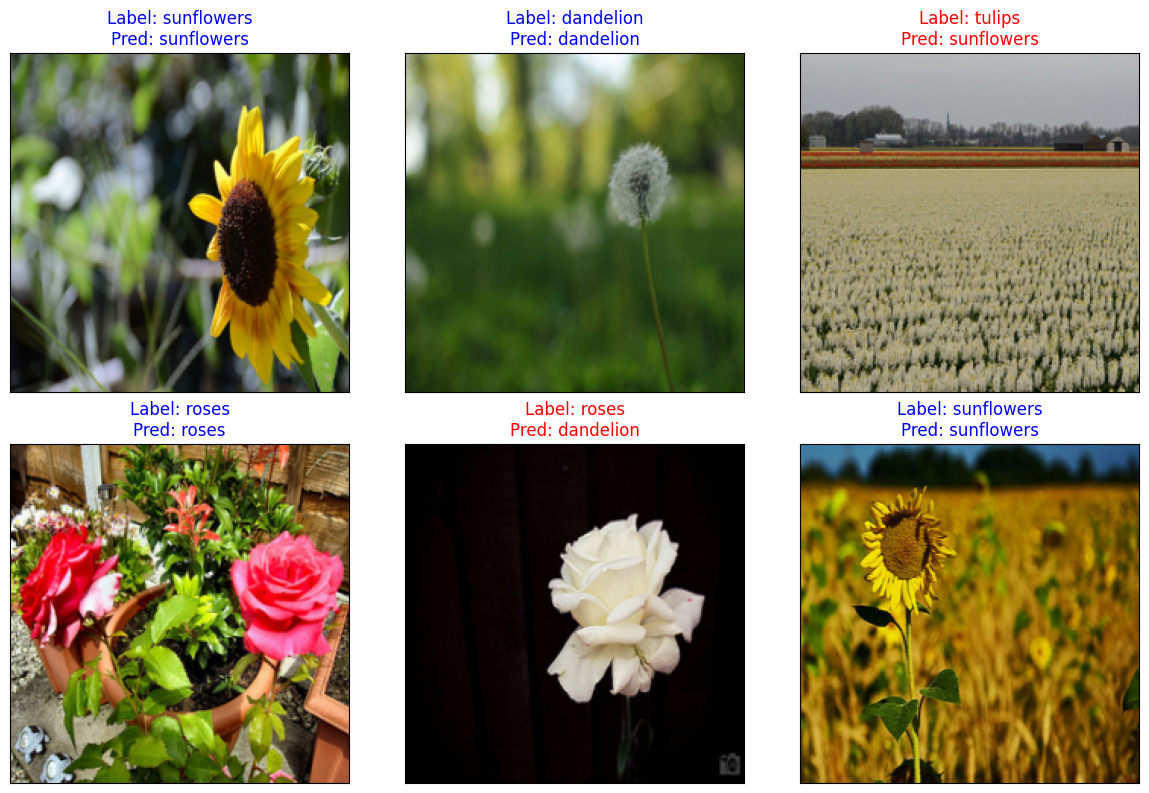

In [ ]:
# ----------------------- 🤖 제미나이 -----------------------
# 코랩에서 plt을 활용해서 실제로 사진이랑 정답이랑 예측을 시각화
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

# 1. 꽃 클래스 이름 정의 (ImageFolder의 원래 순서대로 지정)
# flower_photos 폴더 안의 하위 폴더 순서와 일치해야 합니다.
class_names = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

# 2. 모델을 평가 모드로 전환
model.eval()

# 3. test_loader에서 배치 하나 꺼내기 (이미 GPU에 올라가 있는 상태)
images, labels = next(iter(test_loader))

# 4. 모델의 예측값 계산
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

# 5. 시각화 창 설정 (2행 3열로 총 6개의 이미지 출력)
fig = plt.figure(figsize=(12, 8))

for idx in range(6):
    ax = fig.add_subplot(2, 3, idx + 1, xticks=[], yticks=[])

    # GPU 텐서를 CPU로 가져오고, matplotlib 규격(H, W, C)에 맞게 차원 변경
    img = images[idx].cpu().numpy().transpose((1, 2, 0))

    # 정규화되어 있을 수 있으므로 이미지 스케일 조정 (0~1 사이로 클리핑)
    img = np.clip(img, 0, 1)

    plt.imshow(img)

    # 맞히면 파란색, 틀리면 빨간색 글씨로 타이틀 표시
    actual_idx = labels[idx].item()
    pred_idx = preds[idx].item()

    title_color = "blue" if pred_idx == actual_idx else "red"

    ax.set_title(f"Label: {class_names[actual_idx]}\nPred: {class_names[pred_idx]}",
                 color=title_color, fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# ----------------------- 🗣️ 내 정리  -----------------------
# 20번 학습한거에 추가로 또 20번 더 돌려보기.
# ---------------------------------------------------------

num_epochs = 20

for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0
  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  print(f'Epoch {epoch+1+20}, Loss: {running_loss/len(train_loader)}')

Epoch 21, Loss: 1.1187219956646794
Epoch 22, Loss: 1.1245008655216382
Epoch 23, Loss: 1.1322735172250997
Epoch 24, Loss: 1.1386714305566705
Epoch 25, Loss: 1.1071998023468514
Epoch 26, Loss: 1.1255548661169799
Epoch 27, Loss: 1.095203987930132
Epoch 28, Loss: 1.1100492205308832
Epoch 29, Loss: 1.0930013993512029
Epoch 30, Loss: 1.0874484524778698
Epoch 31, Loss: 1.1016231697538625
Epoch 32, Loss: 1.0982746378235195
Epoch 33, Loss: 1.0867460992025293
Epoch 34, Loss: 1.0903219664874284
Epoch 35, Loss: 1.0673942287331042
Epoch 36, Loss: 1.0609082741581874
Epoch 37, Loss: 1.049496700582297
Epoch 38, Loss: 1.0561475747305413
Epoch 39, Loss: 1.0531621115363163
Epoch 40, Loss: 1.0485306842171627


In [ ]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
  for inputs, labels in test_loader:
    outputs = model(inputs)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

accuracy1 = correct / total
print(f'20번만 학습 했을 때 : {accuracy * 100}%')
print(f'추가로 20번을 더 학습 했을 때 : {accuracy1 * 100}%')

20번만 학습 했을 때 : 58.31062670299727%
추가로 20번을 더 학습 했을 때 : 62.67029972752044%


# <font color='red'>1. 배운 점</font>


<font color='green'>1.   딥러닝 모델의 두 가지 학습 패러다임 이해
- **Training from Scratch**: 가중치(weights=None)를 무작위 난수로 초기화하여 이미지의 기초적인 특징(선, 면 등)조차 모르는 백지 상태에서 모델을 처음부터 가르치는 메커니즘을 작성.
- **Transfer Learning**: 대규모 데이터셋(ImageNet)으로 미리 학습된 거대한 거장 모델(ResNet50)의 구조와 지식을 빌려와, 내 도메인 데이터셋(꽃 분류)에 맞게 출력층을 리폼하고 미세조정하는 흐름을 이해.
2.   파이토치(PyTorch)의 메모리 관리 및 가중치 유지 원리
- 10개의 정답을 내는 모델에 5개 출력으로 바꾸기 위해 모델을 새로 선언(model = CustomResNet50())하였는데, 새로 선언한다면 이전 셀에서 학습했던 지식이 고스란히 사라지며 또 다른 아예 새로운 모델이 된다는 점을 확인.
 - 또한, 앞에서 학습시킨 모델에 전이 학습을 진행하려면 같은 출력 개수를 내도록 설정해야한다는 점을 확인.

# <font color='red'>2. 어려웠던 점</font>


<font color='green'>1.   차원 불일치 에러와 데이터 규격화
- 첫 가짜 데이터 실험 단계에서 정의한 10개짜리 출력층 구조를 꽃 데이터셋(5개 클래스)에 그대로 적용하려 했을 때, 손실 함수(nn.CrossEntropyLoss) 단에서 배열의 크기가 맞지 않아 발생한 RuntimeError를 해결하는 과정을 경험.
2.   하드웨어 가속기(GPU)와 메모리 동기화 이슈
- 데이터는 GPU(cuda) 메모리에 적재되어 있으나 모델은 CPU에 머물러 있을 때 발생하는 RuntimeError: Input type and weight type should be the same 에러를 마주.
- 모델과 데이터를 모두 동일한 장치(model.to(device))에 올려주어야 한다는 인프라적 제어 확인.



# <font color='red'>3. 앞으로의 보완점</font>


<font color='green'>1.   과적합 모니터링 구축
- 학습 루프 내에 실시간 Validation 검증 코드를 추가하고, EarlyStopping 기법을 적용하여 최적의 타이밍에 학습을 종료하는 자동화 시스템을 보완.

# <font color='red'>4. 수행 과정 종합 평가</font>


<font color='green'>1.   서론
- 본 과제는 가상의 무작위 난수 데이터셋을 활용해 이미지 분류 모델의 동작 안정성을 검증한 뒤, 해당 가중치 지식을 유지한 채 진짜 데이터셋인 꽃 이미지(flower_photos) 분류 임무로 자연스럽게 전이시키는 파이프라인 구축을 목표로 진행되었습니다. 딥러닝 가속을 위해 Google Colab의 고성능 NVIDIA A100-SXM4-80GB GPU 환경을 기반으로 모델링을 수행했습니다.

<font color='green'>2.   본론


학습은 총 두 단계의 연속적인 실행 및 관찰 프로세스로 전개되었습니다.

- 1차 난수 학습 및 디바이스 제어:
num_classes=5 규격의 임의 생성 데이터로 ResNet50 기반 커스텀 모델을 10 에포크 동안 선행 학습시켰습니다. 이 과정에서 device 인지 오류 및 CPU-GPU 간 메모리 불일치 에러를 만나, 데이터 로더와 모델을 model.to(device) 코드를 통해 모두 A100 GPU 장치로 일치시키는 연산 환경 동기화를 수행했습니다.
- 2차 누적 전이 학습 및 관찰:
  *   1차 학습이 완료된 후, **모델의 가중치를 포맷하는 20번 초기화 셀**(model = CustomResNet50())을 주석 처리하여 이전 지식을 유지시켰습니다. 데이터 로더에만 진짜 꽃 이미지 데이터를 갈아 끼운 후 20 에포크 동안 추가 학습을 실행한 결과, 손실(Loss) 값이 1.55에서 1.13까지 하향 안정화되는 패턴을 관찰했습니다.
  *   이어서 학습 코드를 재실행하여 에포크를 21~40까지 누적 연장했을 때, Loss가 1.04까지 추가로 하락하는 연속 학습 메커니즘을 확인했습니다.

  

<font color='green'>3.   결론
- 최종적으로 평가 모드(model.eval())를 활성화하고 test_loader를 통해 모델의 성능을 정량적으로 평가했습니다.
  *  20 에포크 시점의 58.31%였던 최종 테스트 정확도는 추가 20 에포크 학습 후 62.67%까지 유의미하게 향상되었습니다.
- 또한 matplotlib.pyplot 시각화 스크립트를 직접 작성 및 실행하여 모델의 예측값(Pred)과 실제 정답(Label)을 직관적인 이미지 맵으로 대조 분석함으로써, 모델이 어떠한 클래스 특징을 잘 포착하고 헷갈려하는지 정성적인 분석까지 성공적으로 완수했습니다.
- 결과적으로 ResNet50 층을 바꾸고, 바닥부터 학습과 전이 학습을 실습하였으며, 런타임을 A100으로 바꾸어도 데이터를 GPU로 올려야 학습이 빠르게 진행되는 것을 경험하였습니다.

🤖 제미나이 대화 원본 : https://gemini.google.com/share/c311b6334ff7


수행시간 : **2시반 30분 소요** ...ㅠ